In [ ]:
# Notebook: Wine ARFF Dataset Analysis & Preprocessing
# Section 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats
from collections import Counter

try:
    from imblearn.over_sampling import RandomOverSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
import joblib

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger("wine_preproc")

DATA_PATH = Path("/Users/egeozbaran/Desktop/ML_2025W_A1/wine-quality-red.arff")
assert DATA_PATH.exists(), f"Data file not found: {DATA_PATH}"

# ARFF loading: 
raw_lines = DATA_PATH.read_text().splitlines()
data_started = False
data_rows = []
for line in raw_lines:
    line = line.strip()
    if not line or line.startswith('%'):  # comment or empty
        continue
    if line.upper().startswith('@DATA'):
        data_started = True
        continue
    if not data_started:
        continue
    # Data line
    parts = [p.strip() for p in line.split(',')]
    if len(parts) == 12:  # 11 features + 1 class
        data_rows.append(parts)

columns = [
    'fixed_acidity','volatile_acidity','citric_acid','residual_sugar','chlorides',
    'free_sulfur_dioxide','total_sulfur_dioxide','density','pH','sulphates','alcohol','class'
]

# Convert to DataFrame with proper dtypes
wine_df = pd.DataFrame(data_rows, columns=columns)
for c in wine_df.columns[:-1]:  # all feature columns numeric
    wine_df[c] = pd.to_numeric(wine_df[c], errors='coerce')
wine_df['class'] = wine_df['class'].astype('category')

logger.info(f"Loaded wine dataset with shape {wine_df.shape}")
print(wine_df.head())


[INFO] Loaded wine dataset with shape (1599, 12)


   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol class  
0      9.4     5  
1      9.8     5  
2      9.8     5  
3      9.8

In [17]:
# 1.2 Data Analysis — Shape & Dimensions
print("Shape:", wine_df.shape)
print("Rows:", wine_df.shape[0], "Cols:", wine_df.shape[1])
print("Columns:\n", list(wine_df.columns))
print("\nInfo:")
wine_df.info(memory_usage='deep')

print("\nDescribe (numeric):")
print(wine_df.describe().T)


Shape: (1599, 12)
Rows: 1599 Cols: 12
Columns:
 ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'class']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed_acidity         1599 non-null   float64 
 1   volatile_acidity      1599 non-null   float64 
 2   citric_acid           1599 non-null   float64 
 3   residual_sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free_sulfur_dioxide   1599 non-null   float64 
 6   total_sulfur_dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 n

                      missing_count  missing_pct
fixed_acidity                     0          0.0
volatile_acidity                  0          0.0
citric_acid                       0          0.0
residual_sugar                    0          0.0
chlorides                         0          0.0
free_sulfur_dioxide               0          0.0
total_sulfur_dioxide              0          0.0
density                           0          0.0
pH                                0          0.0
sulphates                         0          0.0
alcohol                           0          0.0
class                             0          0.0


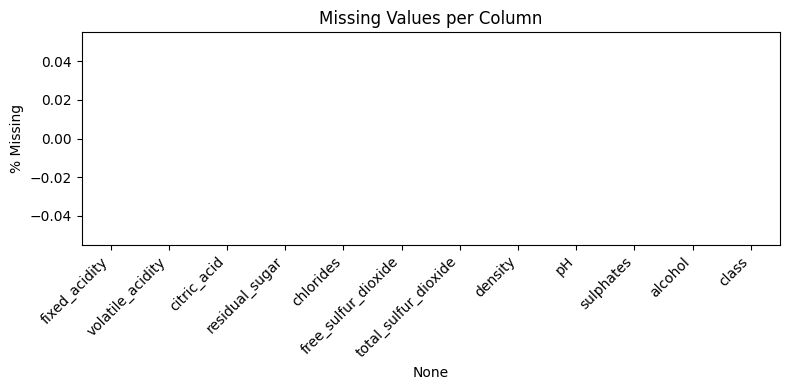

In [18]:
# 1.2 Data Analysis — Missing Values
na_counts = wine_df.isna().sum().sort_values(ascending=False)
na_pct = (na_counts / len(wine_df) * 100).round(2)
na_df = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})
print(na_df)

plt.figure(figsize=(8,4))
sns.barplot(x=na_df.index, y=na_df.missing_pct, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('% Missing')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()


[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


       count    pct
class              
3         10   0.63
4         53   3.31
5        681  42.59
6        638  39.90
7        199  12.45
8         18   1.13


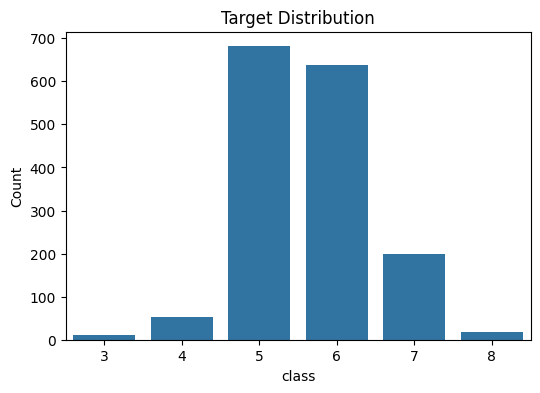

[INFO] Target imbalance check: max proportion 42.59%


Imbalanced? False


In [19]:
# 1.2 Data Analysis — Target Distribution
target_col = 'class'
value_counts = wine_df[target_col].value_counts().sort_index()
proportions = (value_counts / len(wine_df) * 100).round(2)
print(pd.DataFrame({'count': value_counts, 'pct': proportions}))

plt.figure(figsize=(6,4))
sns.countplot(x=wine_df[target_col])
plt.title('Target Distribution')
plt.ylabel('Count')
plt.show()

logger.info(f"Target imbalance check: max proportion {proportions.max()}%")
IMBALANCED = proportions.max() > 60
print("Imbalanced?", IMBALANCED)


In [ ]:
# 1.2 Data Analysis — Outlier Detection (IQR & Z-Score)
num_cols = wine_df.select_dtypes(include=[np.number]).columns.tolist()

num_cols = [c for c in num_cols if c != 'class']

outlier_summary = []
for c in num_cols:
    col = wine_df[c].dropna()
    Q1, Q3 = np.percentile(col, [25, 75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    iqr_outliers = ((wine_df[c] < lower) | (wine_df[c] > upper)).sum()

    z = np.abs(stats.zscore(col))
    z_outliers = (z > 3).sum()

    outlier_summary.append({
        'column': c,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lower': lower, 'upper': upper,
        'iqr_outliers': int(iqr_outliers),
        'z_outliers': int(z_outliers)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('iqr_outliers', ascending=False)
print(outlier_df)


                  column       Q1         Q3        IQR      lower  \
3         residual_sugar   1.9000   2.600000   0.700000   0.850000   
4              chlorides   0.0700   0.090000   0.020000   0.040000   
9              sulphates   0.5500   0.730000   0.180000   0.280000   
6   total_sulfur_dioxide  22.0000  62.000000  40.000000 -38.000000   
0          fixed_acidity   7.1000   9.200000   2.100000   3.950000   
7                density   0.9956   0.997835   0.002235   0.992248   
8                     pH   3.2100   3.400000   0.190000   2.925000   
5    free_sulfur_dioxide   7.0000  21.000000  14.000000 -14.000000   
1       volatile_acidity   0.3900   0.640000   0.250000   0.015000   
10               alcohol   9.5000  11.100000   1.600000   7.100000   
2            citric_acid   0.0900   0.420000   0.330000  -0.405000   

         upper  iqr_outliers  z_outliers  
3     3.650000           155          30  
4     0.120000           112          31  
9     1.000000            59  

In [21]:
# 1.2 Data Analysis — Identify Non-Numerical Columns
non_num_cols = wine_df.select_dtypes(include=['object','category']).columns.tolist()
print("Non-numerical columns:", non_num_cols)


Non-numerical columns: ['class']


In [22]:
# 1.3 Data Preprocessing — Handle Missing Values
numeric_features = [c for c in wine_df.columns if wine_df[c].dtype.kind in 'fc' and c != 'class']
categorical_features = [c for c in wine_df.columns if wine_df[c].dtype.name in ['object','category'] and c != 'class']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

logger.info(f"Numeric features ({len(numeric_features)}): {numeric_features}")
logger.info(f"Categorical features ({len(categorical_features)}): {categorical_features}")


[INFO] Numeric features (11): ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']
[INFO] Categorical features (0): []
[INFO] Categorical features (0): []


In [23]:
# 1.3 Data Preprocessing — Encode Non-Numerical Data (placeholder if any categorical features)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 1.3 Data Preprocessing — Rebalance Target (If Needed)
if IMBALANCED and IMBLEARN_AVAILABLE:
    logger.info("Imbalance detected. Will apply RandomOverSampler after train split.")
elif IMBALANCED and not IMBLEARN_AVAILABLE:
    logger.info("Imbalance detected but imblearn not installed; consider installing or using class_weight later.")
else:
    logger.info("No severe imbalance; proceeding without oversampling.")


[INFO] No severe imbalance; proceeding without oversampling.


In [ ]:
# 1.3 Data Preprocessing — Define IQR Capping Transformer to Avoid Leakage
from sklearn.base import BaseEstimator, TransformerMixin

class IQRCapper(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer that caps numeric columns using IQR bounds.
    For each column, computes Q1/Q3 on fit(X) and caps values outside [Q1-1.5*IQR, Q3+1.5*IQR] on transform(X).
    """
    def __init__(self):
        self.bounds_ = None
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        bounds = {}
        for c in self.feature_names_in_:
            col = pd.to_numeric(X[c], errors='coerce')
            q1, q3 = np.nanpercentile(col, [25, 75])
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            bounds[c] = (lower, upper)
        self.bounds_ = bounds
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c in self.feature_names_in_:
            lower, upper = self.bounds_[c]
            X[c] = pd.to_numeric(X[c], errors='coerce')
            X[c] = np.where(X[c] < lower, lower, X[c])
            X[c] = np.where(X[c] > upper, upper, X[c])
        return X.values

logger.info("Defined IQRCapper to avoid leakage by fitting capping on training data only.")


[INFO] Defined IQRCapper to avoid leakage by fitting capping on training data only.


In [25]:
# 1.3 Data Preprocessing — Split Dataset & Build Leakage-Safe Pipeline
X = wine_df.drop(columns=[target_col])
y = wine_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
logger.info(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Optional oversampling (post-split) if IMBALANCED
if IMBALANCED and IMBLEARN_AVAILABLE:
    ros = RandomOverSampler(random_state=42)
    X_train, y_train = ros.fit_resample(X_train, y_train)
    logger.info(f"Applied RandomOverSampler. New train distribution: {Counter(y_train)}")

# Build ColumnTransformer pipelines with IQRCapper inside numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ('capper', IQRCapper()),
    ('imputer', num_imputer),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline(steps=[('imputer', cat_imputer), ('encoder', encoder)])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', cat_pipeline, categorical_features)
    ],
    remainder='drop'
)

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

full_pipeline.fit(X_train)
X_train_processed = full_pipeline.transform(X_train)
X_test_processed = full_pipeline.transform(X_test)

# Feature names retrieval (numeric after scaler + encoded cats)
num_feature_names = numeric_features
cat_feature_names = []
if categorical_features:
    enc = full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
    cat_feature_names = enc.get_feature_names_out(categorical_features).tolist()
processed_feature_names = num_feature_names + cat_feature_names

logger.info(f"Processed train shape: {X_train_processed.shape}; test shape: {X_test_processed.shape}")
print("First 5 rows (train processed, dense array preview):")
print(pd.DataFrame(X_train_processed[:5], columns=processed_feature_names).head())


[INFO] Train shape: (1279, 11), Test shape: (320, 11)
[INFO] Processed train shape: (1279, 11); test shape: (320, 11)
[INFO] Processed train shape: (1279, 11); test shape: (320, 11)


First 5 rows (train processed, dense array preview):
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0      -0.970082          1.918305    -1.304189       -0.716623  -0.969250   
1      -0.847938          0.605159     0.288670        2.185460   2.231841   
2       2.205652          0.254986     1.162174        0.444210   0.015701   
3       0.190282         -0.328635    -0.019625       -0.053290  -1.461725   
4       1.289575         -1.554238     1.059409       -0.716623  -0.859811   

   free_sulfur_dioxide  total_sulfur_dioxide   density        pH  sulphates  \
0             1.294501             -0.278535 -1.133058 -0.055733  -0.661594   
1             2.837990              2.201663  0.640767 -0.593973  -0.661594   
2            -0.995839             -0.471798  2.178081 -1.266771   0.876976   
3            -0.199199             -0.600639 -0.885285 -0.863092   1.016846   
4            -0.995839             -1.180426  0.286002  0.146106   1.506391   

   

In [26]:
# 1.3 Data Preprocessing — Save Artifacts
ARTIFACT_DIR = Path('/Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

pipeline_path = ARTIFACT_DIR / 'wine_preprocessing_pipeline.joblib'
train_path = ARTIFACT_DIR / 'wine_train_processed.csv'
test_path = ARTIFACT_DIR / 'wine_test_processed.csv'
train_target_path = ARTIFACT_DIR / 'wine_train_target.csv'
test_target_path = ARTIFACT_DIR / 'wine_test_target.csv'

joblib.dump(full_pipeline, pipeline_path)
pd.DataFrame(X_train_processed, columns=processed_feature_names).to_csv(train_path, index=False)
pd.DataFrame(X_test_processed, columns=processed_feature_names).to_csv(test_path, index=False)
y_train.to_csv(train_target_path, index=False)
y_test.to_csv(test_target_path, index=False)

logger.info(f"Saved pipeline to {pipeline_path}")
logger.info(f"Saved processed train to {train_path}")
logger.info(f"Saved processed test to {test_path}")
logger.info(f"Saved target train to {train_target_path}")
logger.info(f"Saved target test to {test_target_path}")

print("Artifacts saved.")


[INFO] Saved pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_preprocessing_pipeline.joblib
[INFO] Saved processed train to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_train_processed.csv
[INFO] Saved processed test to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_test_processed.csv
[INFO] Saved target train to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_train_target.csv
[INFO] Saved target test to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_test_target.csv
[INFO] Saved processed train to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_train_processed.csv
[INFO] Saved processed test to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_test_processed.csv
[INFO] Saved target train to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_train_target.csv
[INFO] Saved target test to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_test_target.csv


Artifacts saved.


In [28]:
# 1.3 Data Preprocessing — Documentation / Assumptions
assumptions = {
    'missing_values': 'No columns exhibited missing values requiring imputation beyond standard median/most_frequent safety.',
    'categorical_features': f"Categorical features used for one-hot: {categorical_features if categorical_features else 'None (only target categorical).'}",
    'imbalance': f"Target imbalance status: {IMBALANCED}. Oversampling applied: {IMBALANCED and IMBLEARN_AVAILABLE}",
    'outlier_strategy': 'IQRCapper transformer fits on train only and caps numeric features inside the pipeline (no leakage).',
    'scaling': 'StandardScaler applied to numeric features to center and scale.',
    'splitting': 'Stratified train/test split with test_size=0.2 and random_state=42.'
}
print("Documentation / Assumptions Summary:")
for k,v in assumptions.items():
    print(f"- {k}: {v}")


Documentation / Assumptions Summary:
- missing_values: No columns exhibited missing values requiring imputation beyond standard median/most_frequent safety.
- categorical_features: Categorical features used for one-hot: None (only target categorical).
- imbalance: Target imbalance status: False. Oversampling applied: False
- outlier_strategy: IQRCapper transformer fits on train only and caps numeric features inside the pipeline (no leakage).
- scaling: StandardScaler applied to numeric features to center and scale.
- splitting: Stratified train/test split with test_size=0.2 and random_state=42.


RandomForest Baseline Results:
- Accuracy: 0.6844
- Macro Precision: 0.4372
- Macro Recall: 0.3859
- Macro F1: 0.4026
- Macro ROC-AUC (OvR): 0.8175
- Macro PR-AUC: 0.5011

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.72      0.76      0.74       136
           6       0.65      0.74      0.69       128
           7       0.76      0.47      0.58        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.40       320
weighted avg       0.66      0.68      0.67       320



/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

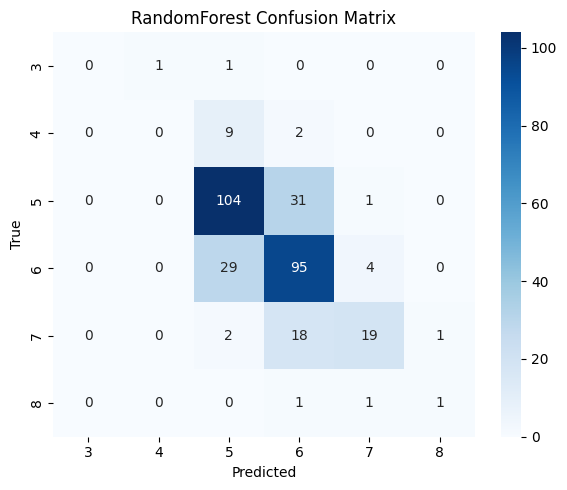

[INFO] Saved RF pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_rf_pipeline.joblib


Runtimes (s): {'train_s': 0.3131400829879567, 'predict_s': 0.04001858294941485}


In [33]:
# 2. Random Forest — Baseline Model (fit with preprocessing, no leakage)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
import time

# Build a fresh modeling pipeline that includes preprocessing
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('rf', rf)])

# Train
start = time.perf_counter()
rf_pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - start

# Evaluate
start = time.perf_counter()
y_pred = rf_pipeline.predict(X_test)
pred_time = time.perf_counter() - start

acc = accuracy_score(y_test, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)
report = classification_report(y_test, y_pred)

# Probability-based metrics
roc_auc_macro = None
pr_auc_macro = None
try:
    y_proba = rf_pipeline.predict_proba(X_test)
    # ROC-AUC (macro, OvR)
    roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    # PR-AUC (macro): binarize y in the same class order as the estimator
    classes_order = rf_pipeline.named_steps['rf'].classes_
    y_test_bin = label_binarize(y_test, classes=classes_order)
    pr_auc_macro = average_precision_score(y_test_bin, y_proba, average='macro')
except Exception as e:
    logger.warning(f"Probability-based metrics partially skipped: {e}")

print("RandomForest Baseline Results:")
print(f"- Accuracy: {acc:.4f}")
print(f"- Macro Precision: {prec_macro:.4f}")
print(f"- Macro Recall: {rec_macro:.4f}")
print(f"- Macro F1: {f1_macro:.4f}")
if roc_auc_macro is not None:
    print(f"- Macro ROC-AUC (OvR): {roc_auc_macro:.4f}")
if pr_auc_macro is not None:
    print(f"- Macro PR-AUC: {pr_auc_macro:.4f}")
print("\nClassification Report:\n", report)

# Confusion Matrix plot
labels = sorted(y_test.unique().tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('RandomForest Confusion Matrix')
plt.tight_layout()
plt.show()

# Store metrics and runtime
rf_results = {
    'accuracy': acc,
    'precision_macro': prec_macro,
    'recall_macro': rec_macro,
    'f1_macro': f1_macro,
    'roc_auc_macro': roc_auc_macro,
    'pr_auc_macro': pr_auc_macro,
}
rf_runtime = {'train_s': train_time, 'predict_s': pred_time}
print("Runtimes (s):", rf_runtime)

# Save model pipeline
rf_model_path = ARTIFACT_DIR / 'wine_rf_pipeline.joblib'
joblib.dump(rf_pipeline, rf_model_path)
logger.info(f"Saved RF pipeline to {rf_model_path}")


RandomForest (class_weight=balanced) Results:
- Accuracy: 0.6875
- Macro Precision: 0.5133
- Macro Recall: 0.3870
- Macro F1: 0.4180
- Macro ROC-AUC (OvR): 0.8377
- Macro PR-AUC: 0.4924

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.74      0.78      0.76       136
           6       0.64      0.73      0.68       128
           7       0.70      0.47      0.57        40
           8       1.00      0.33      0.50         3

    accuracy                           0.69       320
   macro avg       0.51      0.39      0.42       320
weighted avg       0.67      0.69      0.67       320



/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

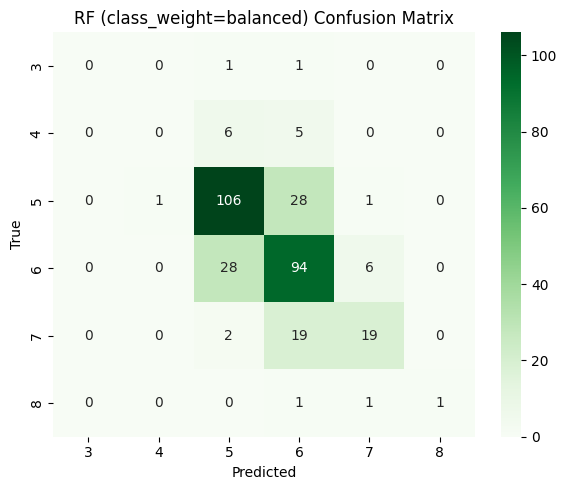

[INFO] Saved RF balanced pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_rf_balanced_pipeline.joblib


Runtimes (s): {'train_s': 0.31385745806619525, 'predict_s': 0.030858541023917496}


In [34]:
# 2.1 Random Forest — Class-Weighted Baseline
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_balanced_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('rf', rf_balanced)])

start = time.perf_counter()
rf_balanced_pipeline.fit(X_train, y_train)
train_time_bal = time.perf_counter() - start

start = time.perf_counter()
y_pred_bal = rf_balanced_pipeline.predict(X_test)
pred_time_bal = time.perf_counter() - start

acc_bal = accuracy_score(y_test, y_pred_bal)
prec_macro_bal, rec_macro_bal, f1_macro_bal, _ = precision_recall_fscore_support(
    y_test, y_pred_bal, average='macro', zero_division=0
)
report_bal = classification_report(y_test, y_pred_bal)

roc_auc_macro_bal = None
pr_auc_macro_bal = None
try:
    y_proba_bal = rf_balanced_pipeline.predict_proba(X_test)
    roc_auc_macro_bal = roc_auc_score(y_test, y_proba_bal, multi_class='ovr', average='macro')
    classes_order_bal = rf_balanced_pipeline.named_steps['rf'].classes_
    y_test_bin_bal = label_binarize(y_test, classes=classes_order_bal)
    pr_auc_macro_bal = average_precision_score(y_test_bin_bal, y_proba_bal, average='macro')
except Exception as e:
    logger.warning(f"Balanced RF probability metrics skipped: {e}")

print("RandomForest (class_weight=balanced) Results:")
print(f"- Accuracy: {acc_bal:.4f}")
print(f"- Macro Precision: {prec_macro_bal:.4f}")
print(f"- Macro Recall: {rec_macro_bal:.4f}")
print(f"- Macro F1: {f1_macro_bal:.4f}")
if roc_auc_macro_bal is not None:
    print(f"- Macro ROC-AUC (OvR): {roc_auc_macro_bal:.4f}")
if pr_auc_macro_bal is not None:
    print(f"- Macro PR-AUC: {pr_auc_macro_bal:.4f}")
print("\nClassification Report:\n", report_bal)

labels = sorted(y_test.unique().tolist())
cm_bal = confusion_matrix(y_test, y_pred_bal, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('RF (class_weight=balanced) Confusion Matrix')
plt.tight_layout()
plt.show()

rf_balanced_results = {
    'accuracy': acc_bal,
    'precision_macro': prec_macro_bal,
    'recall_macro': rec_macro_bal,
    'f1_macro': f1_macro_bal,
    'roc_auc_macro': roc_auc_macro_bal,
    'pr_auc_macro': pr_auc_macro_bal,
}
rf_balanced_runtime = {'train_s': train_time_bal, 'predict_s': pred_time_bal}
print("Runtimes (s):", rf_balanced_runtime)

rf_balanced_model_path = ARTIFACT_DIR / 'wine_rf_balanced_pipeline.joblib'
joblib.dump(rf_balanced_pipeline, rf_balanced_model_path)
logger.info(f"Saved RF balanced pipeline to {rf_balanced_model_path}")


Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Best Params (refit=f1_macro): {'rf__class_weight': 'balanced', 'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best CV f1_macro: 0.3785
RandomForest (GridSearchCV) Test Results:
- Accuracy: 0.6781
- Macro Precision: 0.4241
- Macro Recall: 0.3862
- Macro F1: 0.3999
- Macro ROC-AUC (OvR): 0.8225
- Macro PR-AUC: 0.4775

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.74      0.76      0.75       136
           6       0.64      0.73      0.68       128
           7       0.67      0.50      0.57        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.42      0.39      0.40       320
weighted avg       0.66      0.68      0.67       320



/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

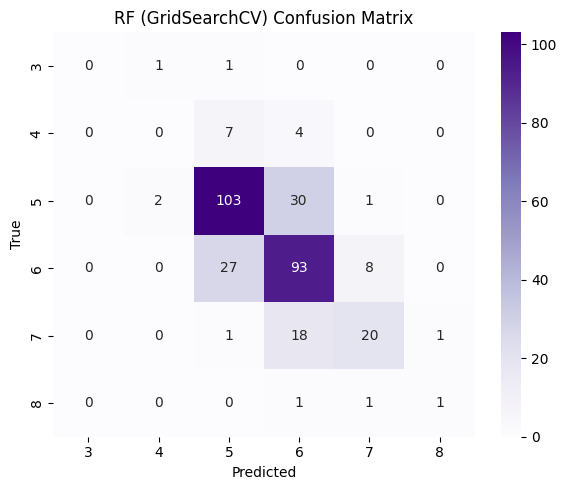

Runtimes (s): {'train_s': 233.97609166696202, 'predict_s': 0.029351499979384243}


[INFO] Saved RF GridSearch pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_rf_grid_pipeline.joblib


In [32]:
# 2.2 Random Forest — GridSearchCV Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
import time

# Base pipeline: preprocessing + RF
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('rf', rf_base)])

# Parameter grid for exhaustive search
param_grid = {
    'rf__n_estimators': [200, 300, 500],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', 0.5],
    'rf__class_weight': [None, 'balanced']
}

# Multi-metric scoring; refit on macro F1
scoring = {
    'f1_macro': 'f1_macro',
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
}

grid = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

start = time.perf_counter()
grid.fit(X_train, y_train)
train_time_grid = time.perf_counter() - start

print("Best Params (refit=f1_macro):", grid.best_params_)
print("Best CV f1_macro:", f"{grid.best_score_:.4f}")

# Evaluate best estimator on test
best_pipe = grid.best_estimator_

start = time.perf_counter()
y_pred_grid = best_pipe.predict(X_test)
pred_time_grid = time.perf_counter() - start

acc_grid = accuracy_score(y_test, y_pred_grid)
prec_macro_grid, rec_macro_grid, f1_macro_grid, _ = precision_recall_fscore_support(
    y_test, y_pred_grid, average='macro', zero_division=0
)
report_grid = classification_report(y_test, y_pred_grid)

# Probability-based metrics (macro ROC-AUC and PR-AUC)
roc_auc_macro_grid = None
pr_auc_macro_grid = None
try:
    y_proba_grid = best_pipe.predict_proba(X_test)
    # ROC-AUC macro (OvR)
    roc_auc_macro_grid = roc_auc_score(y_test, y_proba_grid, multi_class='ovr', average='macro')
    # PR-AUC macro via binarization aligned with estimator class order
    classes_order_grid = best_pipe.named_steps['rf'].classes_
    y_test_bin_grid = label_binarize(y_test, classes=classes_order_grid)
    pr_auc_macro_grid = average_precision_score(y_test_bin_grid, y_proba_grid, average='macro')
except Exception as e:
    logger.warning(f"GridSearch RF probability metrics skipped: {e}")

print("RandomForest (GridSearchCV) Test Results:")
print(f"- Accuracy: {acc_grid:.4f}")
print(f"- Macro Precision: {prec_macro_grid:.4f}")
print(f"- Macro Recall: {rec_macro_grid:.4f}")
print(f"- Macro F1: {f1_macro_grid:.4f}")
if roc_auc_macro_grid is not None:
    print(f"- Macro ROC-AUC (OvR): {roc_auc_macro_grid:.4f}")
if pr_auc_macro_grid is not None:
    print(f"- Macro PR-AUC: {pr_auc_macro_grid:.4f}")
print("\nClassification Report:\n", report_grid)

labels = sorted(y_test.unique().tolist())
cm_grid = confusion_matrix(y_test, y_pred_grid, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('RF (GridSearchCV) Confusion Matrix')
plt.tight_layout()
plt.show()

# Store results and runtime for comparison
rf_grid_results = {
    'best_params': grid.best_params_,
    'cv_best_f1_macro': grid.best_score_,
    'accuracy': acc_grid,
    'precision_macro': prec_macro_grid,
    'recall_macro': rec_macro_grid,
    'f1_macro': f1_macro_grid,
    'roc_auc_macro': roc_auc_macro_grid,
    'pr_auc_macro': pr_auc_macro_grid,
}
rf_grid_runtime = {'train_s': train_time_grid, 'predict_s': pred_time_grid}
print("Runtimes (s):", rf_grid_runtime)

# Save tuned pipeline
rf_grid_model_path = ARTIFACT_DIR / 'wine_rf_grid_pipeline.joblib'
joblib.dump(best_pipe, rf_grid_model_path)
logger.info(f"Saved RF GridSearch pipeline to {rf_grid_model_path}")

Random Forest Model Comparison (sorted by f1_macro):
        model  cv_best_f1_macro  accuracy  precision_macro  recall_macro  f1_macro  roc_auc_macro  pr_auc_macro
  RF Balanced               NaN  0.687500          0.51335      0.387020  0.418030       0.837683      0.492426
  RF Baseline               NaN  0.684375          0.43725      0.385871  0.402623       0.817462      0.501060
RF GridSearch          0.378479  0.678125          0.42411      0.386208  0.399892       0.822504      0.477517


/var/folders/7g/h9x74qfs1xv3thc53rm7_xjw0000gn/T/ipykernel_1538/404968417.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df_sorted, x='model', y='f1_macro', palette='viridis')


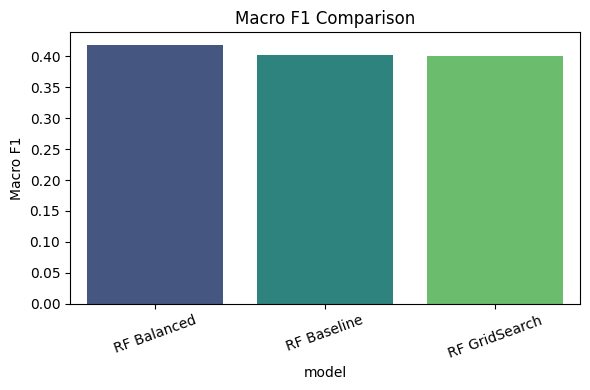

In [ ]:
# 2.3 Random Forest — Comparison Summary
import pandas as pd
comparison_rows = []
if 'rf_results' in globals():
    row = {'model':'RF Baseline', **{k:v for k,v in rf_results.items() if k not in ['best_params','cv_best_f1_macro']}}
    comparison_rows.append(row)
if 'rf_balanced_results' in globals():
    row = {'model':'RF Balanced', **{k:v for k,v in rf_balanced_results.items() if k not in ['best_params','cv_best_f1_macro']}}
    comparison_rows.append(row)
if 'rf_grid_results' in globals():
    row = {'model':'RF GridSearch', 'cv_best_f1_macro': rf_grid_results.get('cv_best_f1_macro'), **{k:v for k,v in rf_grid_results.items() if k not in ['best_params','cv_best_f1_macro']}}
    comparison_rows.append(row)
if 'gb_results' in globals():
    row = {'model':'GB Baseline', **{k:v for k,v in gb_results.items() if k not in ['best_params','cv_best_f1_macro']}}
    comparison_rows.append(row)
if 'gb_grid_results' in globals():
    row = {'model':'GB GridSearch', 'cv_best_f1_macro': gb_grid_results.get('cv_best_f1_macro'), **{k:v for k,v in gb_grid_results.items() if k not in ['best_params','cv_best_f1_macro']}}
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
# Reorder columns for readability
cols_order = ['model','cv_best_f1_macro','accuracy','precision_macro','recall_macro','f1_macro','roc_auc_macro','pr_auc_macro']
comparison_df = comparison_df[[c for c in cols_order if c in comparison_df.columns]]
comparison_df_sorted = comparison_df.sort_values(by='f1_macro', ascending=False)
print('Model Comparison (sorted by f1_macro):')
print(comparison_df_sorted.to_string(index=False))

# Optional: bar plot of macro F1
plt.figure(figsize=(7,4))
sns.barplot(data=comparison_df_sorted, x='model', y='f1_macro', palette='viridis')
plt.title('Macro F1 Comparison')
plt.ylabel('Macro F1')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

GradientBoosting Baseline Results:
- Accuracy: 0.6562
- Macro Precision: 0.5306
- Macro Recall: 0.4115
- Macro F1: 0.4398
- Macro ROC-AUC (OvR): 0.8377
- Macro PR-AUC: 0.4585

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.20      0.09      0.12        11
           5       0.70      0.71      0.70       136
           6       0.63      0.66      0.65       128
           7       0.66      0.68      0.67        40
           8       1.00      0.33      0.50         3

    accuracy                           0.66       320
   macro avg       0.53      0.41      0.44       320
weighted avg       0.65      0.66      0.65       320



/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

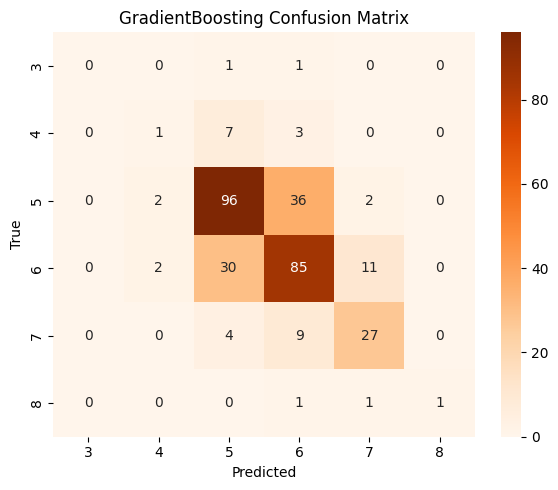

[INFO] Saved GradientBoosting pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_gb_pipeline.joblib


Runtimes (s): {'train_s': 1.5276213749311864, 'predict_s': 0.007737332955002785}


In [37]:
# 3. Gradient Boosting — Baseline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
import time

gb_clf = GradientBoostingClassifier(random_state=42)
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('gb', gb_clf)])

start = time.perf_counter()
gb_pipeline.fit(X_train, y_train)
train_time_gb = time.perf_counter() - start

start = time.perf_counter()
y_pred_gb = gb_pipeline.predict(X_test)
pred_time_gb = time.perf_counter() - start

acc_gb = accuracy_score(y_test, y_pred_gb)
prec_macro_gb, rec_macro_gb, f1_macro_gb, _ = precision_recall_fscore_support(
    y_test, y_pred_gb, average='macro', zero_division=0
)
report_gb = classification_report(y_test, y_pred_gb)

roc_auc_macro_gb = None
pr_auc_macro_gb = None
try:
    # GradientBoostingClassifier has predict_proba
    y_proba_gb = gb_pipeline.predict_proba(X_test)
    roc_auc_macro_gb = roc_auc_score(y_test, y_proba_gb, multi_class='ovr', average='macro')
    classes_order_gb = gb_pipeline.named_steps['gb'].classes_
    y_test_bin_gb = label_binarize(y_test, classes=classes_order_gb)
    pr_auc_macro_gb = average_precision_score(y_test_bin_gb, y_proba_gb, average='macro')
except Exception as e:
    logger.warning(f"GB probability metrics skipped: {e}")

print("GradientBoosting Baseline Results:")
print(f"- Accuracy: {acc_gb:.4f}")
print(f"- Macro Precision: {prec_macro_gb:.4f}")
print(f"- Macro Recall: {rec_macro_gb:.4f}")
print(f"- Macro F1: {f1_macro_gb:.4f}")
if roc_auc_macro_gb is not None:
    print(f"- Macro ROC-AUC (OvR): {roc_auc_macro_gb:.4f}")
if pr_auc_macro_gb is not None:
    print(f"- Macro PR-AUC: {pr_auc_macro_gb:.4f}")
print("\nClassification Report:\n", report_gb)

labels = sorted(y_test.unique().tolist())
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('GradientBoosting Confusion Matrix')
plt.tight_layout()
plt.show()

gb_results = {
    'accuracy': acc_gb,
    'precision_macro': prec_macro_gb,
    'recall_macro': rec_macro_gb,
    'f1_macro': f1_macro_gb,
    'roc_auc_macro': roc_auc_macro_gb,
    'pr_auc_macro': pr_auc_macro_gb,
}
gb_runtime = {'train_s': train_time_gb, 'predict_s': pred_time_gb}
print("Runtimes (s):", gb_runtime)

gb_model_path = ARTIFACT_DIR / 'wine_gb_pipeline.joblib'
joblib.dump(gb_pipeline, gb_model_path)
logger.info(f"Saved GradientBoosting pipeline to {gb_model_path}")

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

GB Best Params (refit=f1_macro): {'gb__learning_rate': 0.1, 'gb__max_depth': 3, 'gb__min_samples_leaf': 4, 'gb__min_samples_split': 10, 'gb__n_estimators': 300, 'gb__subsample': 1.0}
GB Best CV f1_macro: 0.3832
GradientBoosting (GridSearchCV) Test Results:
- Accuracy: 0.6500
- Macro Precision: 0.4807
- Macro Recall: 0.3833
- Macro F1: 0.4040
- Macro ROC-AUC (OvR): 0.7561
- Macro PR-AUC: 0.4387

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.74      0.72       136
           6       0.61      0.66      0.63       128
           7       0.56      0.57      0.57        40
           8       1.00      0.33      0.50         3

    accuracy                           0.65       320
   macro avg       0.48      0.38      0.40       320
weighted avg       0.63      0.65      0.64       320



/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

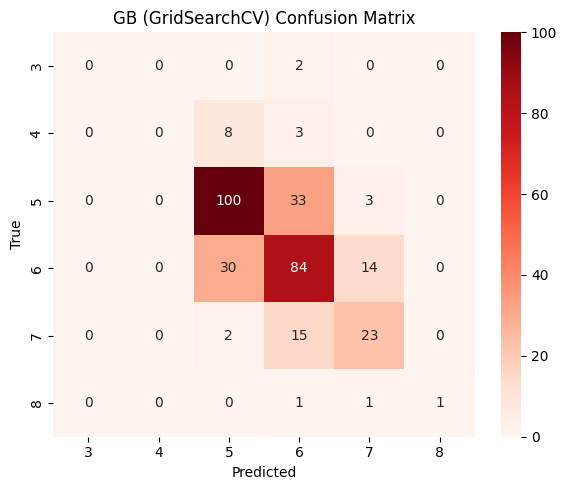

[INFO] Saved GB GridSearch pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_gb_grid_pipeline.joblib


Runtimes (s): {'train_s': 536.5032602499705, 'predict_s': 0.01384324999526143}


In [38]:
# 3.1 Gradient Boosting — GridSearchCV Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
import time

gb_base = GradientBoostingClassifier(random_state=42)
gb_grid_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('gb', gb_base)])

gb_param_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.05, 0.1, 0.2],
    'gb__max_depth': [3, 4, 5],
    'gb__min_samples_split': [2, 5, 10],
    'gb__min_samples_leaf': [1, 2, 4],
    'gb__subsample': [1.0, 0.8]
}

gb_scoring = {
    'f1_macro': 'f1_macro',
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
}

gb_grid = GridSearchCV(
    estimator=gb_grid_pipeline,
    param_grid=gb_param_grid,
    scoring=gb_scoring,
    refit='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

start = time.perf_counter()
gb_grid.fit(X_train, y_train)
train_time_gb_grid = time.perf_counter() - start

print("GB Best Params (refit=f1_macro):", gb_grid.best_params_)
print("GB Best CV f1_macro:", f"{gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
start = time.perf_counter()
y_pred_gb_grid = gb_best.predict(X_test)
pred_time_gb_grid = time.perf_counter() - start

acc_gb_grid = accuracy_score(y_test, y_pred_gb_grid)
prec_macro_gb_grid, rec_macro_gb_grid, f1_macro_gb_grid, _ = precision_recall_fscore_support(
    y_test, y_pred_gb_grid, average='macro', zero_division=0
)
report_gb_grid = classification_report(y_test, y_pred_gb_grid)

roc_auc_macro_gb_grid = None
pr_auc_macro_gb_grid = None
try:
    y_proba_gb_grid = gb_best.predict_proba(X_test)
    roc_auc_macro_gb_grid = roc_auc_score(y_test, y_proba_gb_grid, multi_class='ovr', average='macro')
    classes_order_gb_grid = gb_best.named_steps['gb'].classes_
    y_test_bin_gb_grid = label_binarize(y_test, classes=classes_order_gb_grid)
    pr_auc_macro_gb_grid = average_precision_score(y_test_bin_gb_grid, y_proba_gb_grid, average='macro')
except Exception as e:
    logger.warning(f"GB Grid probability metrics skipped: {e}")

print("GradientBoosting (GridSearchCV) Test Results:")
print(f"- Accuracy: {acc_gb_grid:.4f}")
print(f"- Macro Precision: {prec_macro_gb_grid:.4f}")
print(f"- Macro Recall: {rec_macro_gb_grid:.4f}")
print(f"- Macro F1: {f1_macro_gb_grid:.4f}")
if roc_auc_macro_gb_grid is not None:
    print(f"- Macro ROC-AUC (OvR): {roc_auc_macro_gb_grid:.4f}")
if pr_auc_macro_gb_grid is not None:
    print(f"- Macro PR-AUC: {pr_auc_macro_gb_grid:.4f}")
print("\nClassification Report:\n", report_gb_grid)

labels = sorted(y_test.unique().tolist())
cm_gb_grid = confusion_matrix(y_test, y_pred_gb_grid, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb_grid, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('GB (GridSearchCV) Confusion Matrix')
plt.tight_layout()
plt.show()

gb_grid_results = {
    'best_params': gb_grid.best_params_,
    'cv_best_f1_macro': gb_grid.best_score_,
    'accuracy': acc_gb_grid,
    'precision_macro': prec_macro_gb_grid,
    'recall_macro': rec_macro_gb_grid,
    'f1_macro': f1_macro_gb_grid,
    'roc_auc_macro': roc_auc_macro_gb_grid,
    'pr_auc_macro': pr_auc_macro_gb_grid,
}
gb_grid_runtime = {'train_s': train_time_gb_grid, 'predict_s': pred_time_gb_grid}
print("Runtimes (s):", gb_grid_runtime)

gb_grid_model_path = ARTIFACT_DIR / 'wine_gb_grid_pipeline.joblib'
from joblib import dump
dump(gb_best, gb_grid_model_path)
logger.info(f"Saved GB GridSearch pipeline to {gb_grid_model_path}")

SVM (RBF) Baseline Results:
- Accuracy: 0.5969
- Macro Precision: 0.3057
- Macro Recall: 0.2726
- Macro F1: 0.2756
- Macro ROC-AUC (OvR): 0.8316
- Macro PR-AUC: 0.3660

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.65      0.73      0.69       136
           6       0.54      0.63      0.58       128
           7       0.65      0.28      0.39        40
           8       0.00      0.00      0.00         3

    accuracy                           0.60       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.60      0.57       320



/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

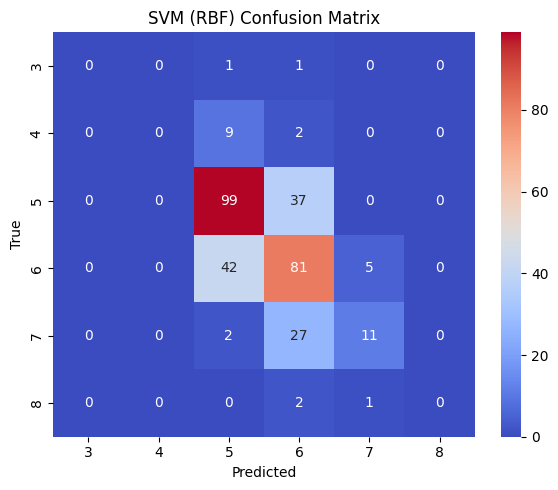

[INFO] Saved SVM (RBF) pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_svm_rbf_pipeline.joblib


Runtimes (s): {'train_s': 0.23061158298514783, 'predict_s': 0.021622125059366226}


In [39]:
# 4. Support Vector Machine (SVM) — Baseline (RBF kernel)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
import time

# SVM with probability=True to enable ROC/PR AUC
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('svm', svm_clf)])

start = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
train_time_svm = time.perf_counter() - start

start = time.perf_counter()
y_pred_svm = svm_pipeline.predict(X_test)
pred_time_svm = time.perf_counter() - start

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_macro_svm, rec_macro_svm, f1_macro_svm, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, average='macro', zero_division=0
)
report_svm = classification_report(y_test, y_pred_svm)

roc_auc_macro_svm = None
pr_auc_macro_svm = None
try:
    y_proba_svm = svm_pipeline.predict_proba(X_test)
    roc_auc_macro_svm = roc_auc_score(y_test, y_proba_svm, multi_class='ovr', average='macro')
    classes_order_svm = svm_pipeline.named_steps['svm'].classes_
    y_test_bin_svm = label_binarize(y_test, classes=classes_order_svm)
    pr_auc_macro_svm = average_precision_score(y_test_bin_svm, y_proba_svm, average='macro')
except Exception as e:
    logger.warning(f"SVM probability metrics skipped: {e}")

print("SVM (RBF) Baseline Results:")
print(f"- Accuracy: {acc_svm:.4f}")
print(f"- Macro Precision: {prec_macro_svm:.4f}")
print(f"- Macro Recall: {rec_macro_svm:.4f}")
print(f"- Macro F1: {f1_macro_svm:.4f}")
if roc_auc_macro_svm is not None:
    print(f"- Macro ROC-AUC (OvR): {roc_auc_macro_svm:.4f}")
if pr_auc_macro_svm is not None:
    print(f"- Macro PR-AUC: {pr_auc_macro_svm:.4f}")
print("\nClassification Report:\n", report_svm)

labels = sorted(y_test.unique().tolist())
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='coolwarm', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM (RBF) Confusion Matrix')
plt.tight_layout()
plt.show()

svm_results = {
    'accuracy': acc_svm,
    'precision_macro': prec_macro_svm,
    'recall_macro': rec_macro_svm,
    'f1_macro': f1_macro_svm,
    'roc_auc_macro': roc_auc_macro_svm,
    'pr_auc_macro': pr_auc_macro_svm,
}
svm_runtime = {'train_s': train_time_svm, 'predict_s': pred_time_svm}
print("Runtimes (s):", svm_runtime)

svm_model_path = ARTIFACT_DIR / 'wine_svm_rbf_pipeline.joblib'
joblib.dump(svm_pipeline, svm_model_path)
logger.info(f"Saved SVM (RBF) pipeline to {svm_model_path}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/egeozbaran/venvs/dataenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

SVM Best Params (refit=f1_macro): {'svm__C': 3, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale'}
SVM Best CV f1_macro: 0.3779
SVM (RBF) GridSearchCV Test Results:
- Accuracy: 0.5469
- Macro Precision: 0.3512
- Macro Recall: 0.4600
- Macro F1: 0.3745
- Macro ROC-AUC (OvR): 0.8365
- Macro PR-AUC: 0.4109

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.14      0.36      0.20        11
           5       0.69      0.60      0.64       136
           6       0.60      0.48      0.53       128
           7       0.46      0.65      0.54        40
           8       0.22      0.67      0.33         3

    accuracy                           0.55       320
   macro avg       0.35      0.46      0.37       320
weighted avg       0.60      0.55      0.56       320



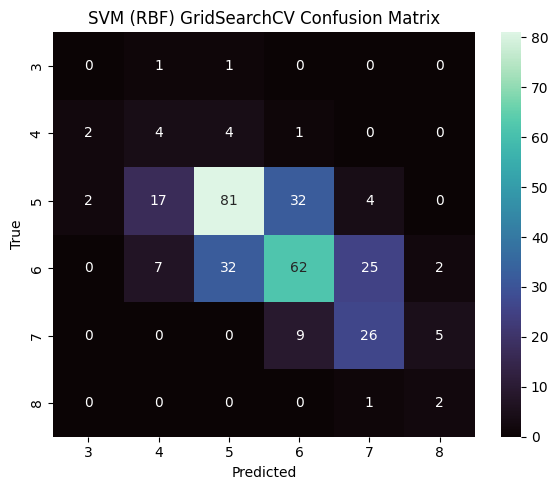

[INFO] Saved SVM GridSearch pipeline to /Users/egeozbaran/Desktop/ML_2025W_A1/wine_artifacts/wine_svm_grid_pipeline.joblib


Runtimes (s): {'train_s': 5.511853542062454, 'predict_s': 0.02405995794106275}


In [40]:
# 4.1 Support Vector Machine (SVM) — GridSearchCV Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
import time

# Base pipeline: preprocessing + SVM (RBF)
svm_base = SVC(kernel='rbf', probability=True, random_state=42)
svm_grid_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('svm', svm_base)])

# Parameter grid — keep reasonable for runtime
svm_param_grid = {
    'svm__C': [0.1, 1, 3, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001],
    'svm__class_weight': [None, 'balanced']
}

# Multi-metric scoring; refit on macro F1
svm_scoring = {
    'f1_macro': 'f1_macro',
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
}

svm_grid = GridSearchCV(
    estimator=svm_grid_pipeline,
    param_grid=svm_param_grid,
    scoring=svm_scoring,
    refit='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

start = time.perf_counter()
svm_grid.fit(X_train, y_train)
train_time_svm_grid = time.perf_counter() - start

print("SVM Best Params (refit=f1_macro):", svm_grid.best_params_)
print("SVM Best CV f1_macro:", f"{svm_grid.best_score_:.4f}")

svm_best = svm_grid.best_estimator_
start = time.perf_counter()
y_pred_svm_grid = svm_best.predict(X_test)
pred_time_svm_grid = time.perf_counter() - start

acc_svm_grid = accuracy_score(y_test, y_pred_svm_grid)
prec_macro_svm_grid, rec_macro_svm_grid, f1_macro_svm_grid, _ = precision_recall_fscore_support(
    y_test, y_pred_svm_grid, average='macro', zero_division=0
)
report_svm_grid = classification_report(y_test, y_pred_svm_grid)

roc_auc_macro_svm_grid = None
pr_auc_macro_svm_grid = None
try:
    y_proba_svm_grid = svm_best.predict_proba(X_test)
    roc_auc_macro_svm_grid = roc_auc_score(y_test, y_proba_svm_grid, multi_class='ovr', average='macro')
    classes_order_svm_grid = svm_best.named_steps['svm'].classes_
    y_test_bin_svm_grid = label_binarize(y_test, classes=classes_order_svm_grid)
    pr_auc_macro_svm_grid = average_precision_score(y_test_bin_svm_grid, y_proba_svm_grid, average='macro')
except Exception as e:
    logger.warning(f"SVM Grid probability metrics skipped: {e}")

print("SVM (RBF) GridSearchCV Test Results:")
print(f"- Accuracy: {acc_svm_grid:.4f}")
print(f"- Macro Precision: {prec_macro_svm_grid:.4f}")
print(f"- Macro Recall: {rec_macro_svm_grid:.4f}")
print(f"- Macro F1: {f1_macro_svm_grid:.4f}")
if roc_auc_macro_svm_grid is not None:
    print(f"- Macro ROC-AUC (OvR): {roc_auc_macro_svm_grid:.4f}")
if pr_auc_macro_svm_grid is not None:
    print(f"- Macro PR-AUC: {pr_auc_macro_svm_grid:.4f}")
print("\nClassification Report:\n", report_svm_grid)

labels = sorted(y_test.unique().tolist())
cm_svm_grid = confusion_matrix(y_test, y_pred_svm_grid, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm_grid, annot=True, fmt='d', cmap='mako', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM (RBF) GridSearchCV Confusion Matrix')
plt.tight_layout()
plt.show()

svm_grid_results = {
    'best_params': svm_grid.best_params_,
    'cv_best_f1_macro': svm_grid.best_score_,
    'accuracy': acc_svm_grid,
    'precision_macro': prec_macro_svm_grid,
    'recall_macro': rec_macro_svm_grid,
    'f1_macro': f1_macro_svm_grid,
    'roc_auc_macro': roc_auc_macro_svm_grid,
    'pr_auc_macro': pr_auc_macro_svm_grid,
}
svm_grid_runtime = {'train_s': train_time_svm_grid, 'predict_s': pred_time_svm_grid}
print("Runtimes (s):", svm_grid_runtime)

svm_grid_model_path = ARTIFACT_DIR / 'wine_svm_grid_pipeline.joblib'
from joblib import dump
dump(svm_best, svm_grid_model_path)
logger.info(f"Saved SVM GridSearch pipeline to {svm_grid_model_path}")

In [41]:
# Updated model comparison including SVM variants
import pandas as pd

rows = []

def add_row(name, res_var, runtime_var=None):
    if res_var is None:
        return
    row = {
        'model': name,
        'accuracy': res_var.get('accuracy'),
        'precision_macro': res_var.get('precision_macro'),
        'recall_macro': res_var.get('recall_macro'),
        'f1_macro': res_var.get('f1_macro'),
        'roc_auc_macro': res_var.get('roc_auc_macro'),
        'pr_auc_macro': res_var.get('pr_auc_macro'),
    }
    if runtime_var is not None:
        row['train_s'] = runtime_var.get('train_s')
        row['predict_s'] = runtime_var.get('predict_s')
    rows.append(row)

add_row('RandomForest (baseline)', globals().get('rf_results'), globals().get('rf_runtime'))
add_row('RandomForest (class_weight=balanced)', globals().get('rf_balanced_results'), globals().get('rf_balanced_runtime'))
add_row('RandomForest (GridSearch)', globals().get('rf_grid_results'), globals().get('rf_grid_runtime'))
add_row('GradientBoosting (baseline)', globals().get('gb_results'), globals().get('gb_runtime'))
add_row('GradientBoosting (GridSearch)', globals().get('gb_grid_results'), globals().get('gb_grid_runtime'))
add_row('SVM RBF (baseline)', globals().get('svm_results'), globals().get('svm_runtime'))
add_row('SVM RBF (GridSearch)', globals().get('svm_grid_results'), globals().get('svm_grid_runtime'))

comparison_df = pd.DataFrame(rows)
comparison_df_sorted = comparison_df.sort_values(by='f1_macro', ascending=False)
print('Models sorted by Macro F1 (desc):')
display(comparison_df_sorted)

best = comparison_df_sorted.iloc[0] if not comparison_df_sorted.empty else None
if best is not None:
    print(f"\nBest by Macro F1: {best['model']}  F1={best['f1_macro']:.4f}  Acc={best['accuracy']:.4f}")

Models sorted by Macro F1 (desc):


,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro,pr_auc_macro,train_s,predict_s
3,GradientBoosting (baseline),0.656250,0.530636,0.411531,0.439797,0.837741,0.458494,1.527621,0.007737
1,RandomForest (class_weight=balanced),0.687500,0.513350,0.387020,0.418030,0.837683,0.492426,0.313857,0.030859
4,GradientBoosting (GridSearch),0.650000,0.480659,0.383313,0.404020,0.756080,0.438675,536.503260,0.013843
0,RandomForest (baseline),0.684375,0.437250,0.385871,0.402623,0.817462,0.501060,0.313140,0.040019
2,RandomForest (GridSearch),0.678125,0.424110,0.386208,0.399892,0.822504,0.477517,233.976092,0.029351
6,SVM RBF (GridSearch),0.546875,0.351172,0.460044,0.374546,0.836455,0.410876,5.511854,0.024060
5,SVM RBF (baseline),0.596875,0.305686,0.272626,0.275637,0.831600,0.365955,0.230612,0.021622



Best by Macro F1: GradientBoosting (baseline)  F1=0.4398  Acc=0.6562
